In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


## Simulaatio

In [4]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [5]:
list_AC_stark_vals=[np.float64(2.9871900648194566e-05), np.float64(9.498067552726481e-05), np.float64(0.00018467000693786622), np.float64(0.00030893989487999865), np.float64(0.0004677903393536623), np.float64(0.0006512213403588572), np.float64(0.0008592328978955829), np.float64(0.0011118250119638402), np.float64(0.0013789976825636285), np.float64(0.0016807509096949476), np.float64(0.0020370846933577993), np.float64(0.0023479990335521796), np.float64(0.0027734939302780925), np.float64(0.0031435693835355385), np.float64(0.0036182253933245115), np.float64(0.004067461959645018), np.float64(0.004561279082497056), np.float64(0.005049676761880622), np.float64(0.005582654997795725), np.float64(0.006190213790242355)]

In [6]:
def sim_pulse(f_d,f_supp,A,evolution,dim,f_rabi,K=60,t_ramp=5,verbose=False,p=1):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    t_gap=np.pi/(f_supp)

    N_edge1 = int((t_ramp*2+t_gap/2)/dt)
    N_edge2 = int((t_ramp*2-t_gap/2)/dt)

    N_pulse=int(2*np.pi/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse1 = pulses.Pulse(f_d,f_ef,[pulses.gaussian(t_ramp*2-t_gap/2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge2,N_pulse,N_edge1],time_unit=dt,offset_input=0)
    pulse2 = pulses.Pulse(f_d,f_ef,[pulses.gaussian(t_ramp*2+t_gap/2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge1,N_pulse,N_edge2],time_unit=dt,offset_input=t_gap*f_d)

    combined_pulse = (pulse1.raw + pulse2.raw)/2
    m = combined_pulse[N_edge1:-N_edge1].max()

    if verbose:
        plt.figure()
        plt.plot(pulse1.time_vals,combined_pulse/m)
        plt.xlabel("Aika (ms)")
        plt.ylabel("Normalisoitu amplitudi")
        plt.title("Yhdistetty pulssi")
        plt.show()

    U_floquet=evolution.U_floquet(A*combined_pulse[N_edge1:N_edge1+K]/m,dt)
    U_floquet=np.linalg.matrix_power(U_floquet,p)

    #Alustetaan kubitin tila perustilaan
    psi_eig_accum = np.zeros(dim, dtype=complex)
    psi_eig_accum[0] = 1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    for i in range(0, N_edge1): #Aikakehitys nousevalle rampille
        psi_eig_accum = evolution.U(A*combined_pulse[i], dt) @ psi_eig_accum

    #Simuloitujen pulssien määrä/K koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (K*dt)
    N_sim=int(N_pulse/(K*p))

    #Simulaatio pulsseille
    for k in range(0,N_sim):
        psi_eig = psi_eig_accum

        #Laskevan rampin simulaatio
        pulse1 = pulses.Pulse(f_d,f_ef,[pulses.gaussian(t_ramp*2-t_gap/2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge2,K*p*k,N_edge1],time_unit=dt,offset_input=0)
        pulse2 = pulses.Pulse(f_d,f_ef,[pulses.gaussian(t_ramp*2+t_gap/2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge1,K*p*k,N_edge2],time_unit=dt,offset_input=t_gap*f_d)
        combined_pulse = (pulse1.raw + pulse2.raw)/2

        remainder = len(combined_pulse)-N_edge1-K*p*k

        for i in range(0, remainder): #Aikakehitys
            psi_eig = evolution_eigenbasis.U(A*combined_pulse[N_edge1+K*p*k+i]/m, dt) @ psi_eig
        last_vals.append(np.abs(psi_eig)**2)
        psi_eig_accum = U_floquet @ psi_eig_accum #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla


    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([a[1] for a in last_vals])
    f_vals = np.array([a[2] for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_pulse)*K*p*dt + 2*t_ramp

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    index = np.argmax(e_vals)
    T_pulse = pulse_times[index]
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(f_d,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]

    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 0.13:
            sim_vals = sim_pulse(f_d,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,p=10)
        else:
            sim_vals = sim_pulse(f_d,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,p=1)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_ef-ω_suppressed (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

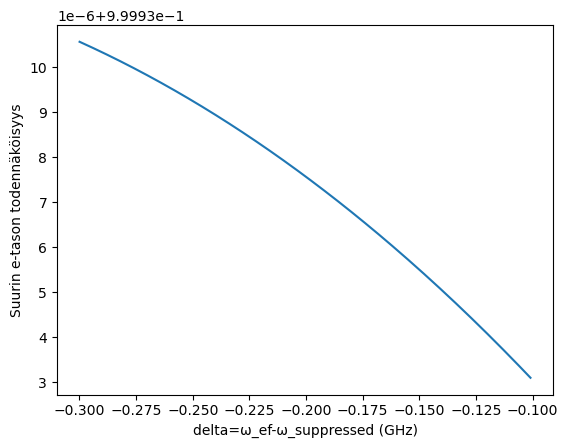

Amplitudi (GHz): 0.012744300694754308
AC-stark siirtymä (GHz): -0.2999601280993518
E-tason suurin todennäköisyys: 0.9999942980764295
Pulssin pituus (ns): 254.0442325173277
Rabi-taajuus (fourier):  0.0021635422175466123


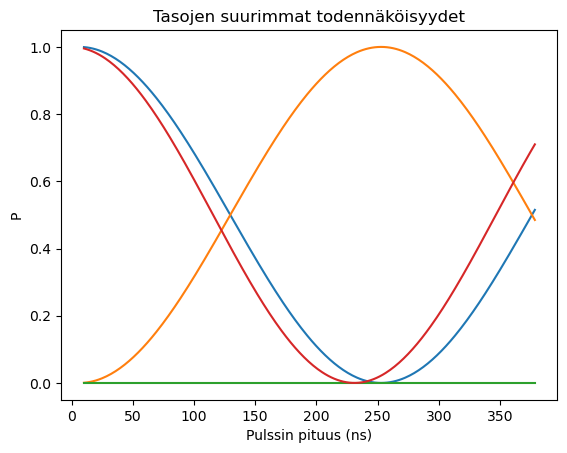

---------------------------------------------


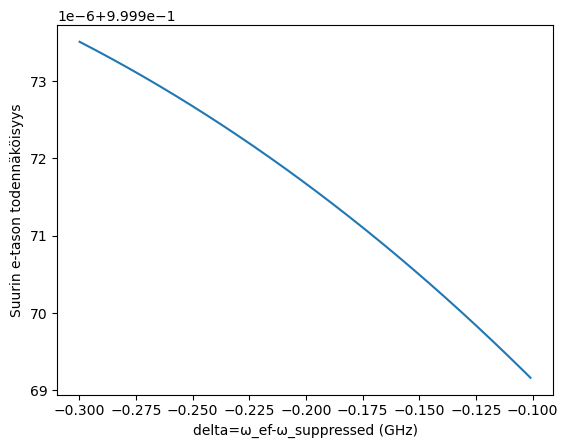

Amplitudi (GHz): 0.021464085380638837
AC-stark siirtymä (GHz): -0.2998950193244727
E-tason suurin todennäköisyys: 0.9999805361674756
Pulssin pituus (ns): 152.975043730643
Rabi-taajuus (fourier):  0.003644381377009103


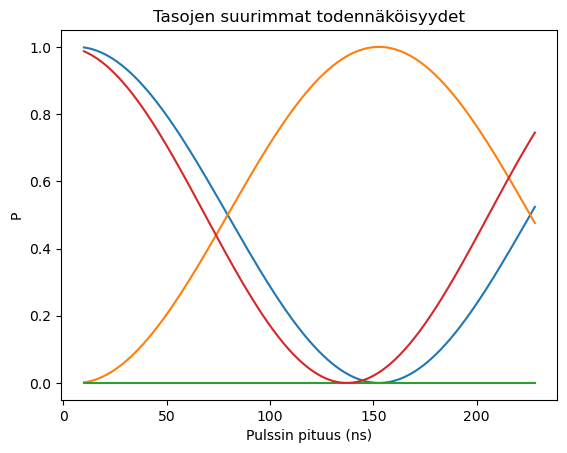

---------------------------------------------


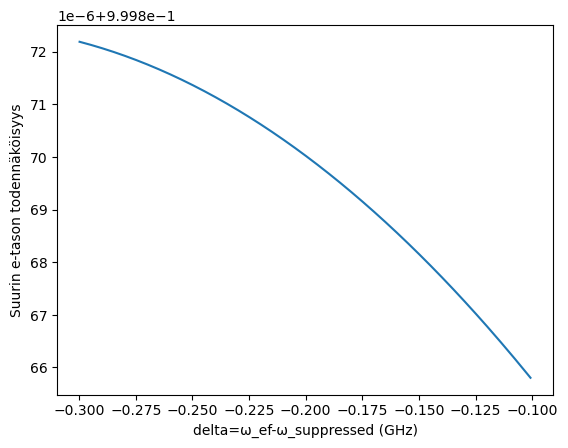

Amplitudi (GHz): 0.030183870066523365
AC-stark siirtymä (GHz): -0.29979532999306213
E-tason suurin todennäköisyys: 0.9999627830541293
Pulssin pituus (ns): 111.06820975814617
Rabi-taajuus (fourier):  0.00512690842942647


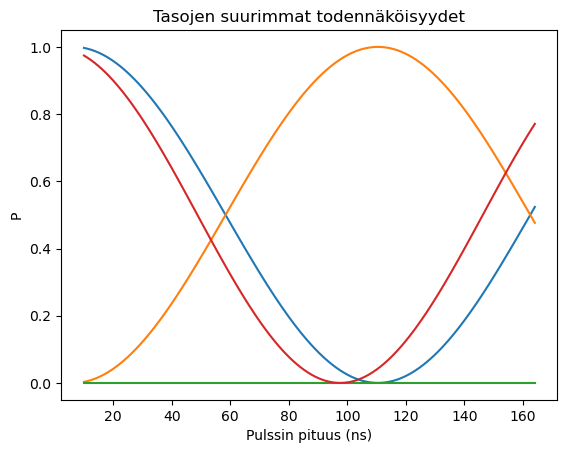

---------------------------------------------


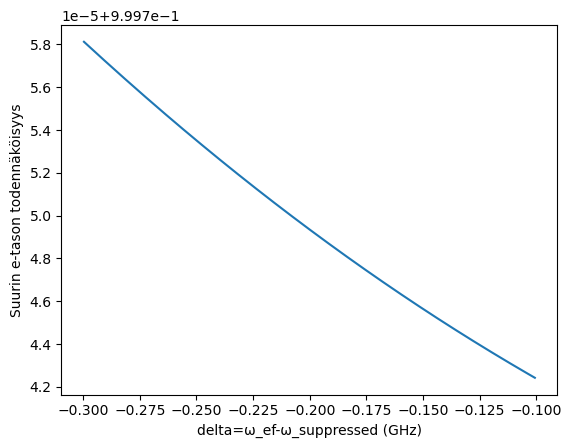

Amplitudi (GHz): 0.03890365475240789
AC-stark siirtymä (GHz): -0.29966106010512
E-tason suurin todennäköisyys: 0.9999369882476044
Pulssin pituus (ns): 86.41705432102145
Rabi-taajuus (fourier):  0.00660967180928821


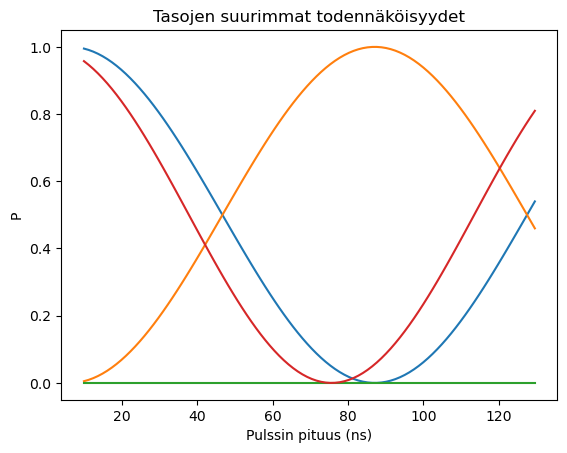

---------------------------------------------


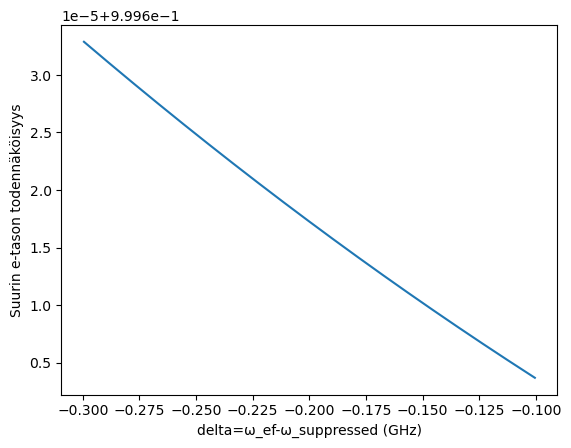

Amplitudi (GHz): 0.04762343943829242
AC-stark siirtymä (GHz): -0.2994922096606463
E-tason suurin todennäköisyys: 0.9999035171601366
Pulssin pituus (ns): 71.62627264697414
Rabi-taajuus (fourier):  0.008093189735230103


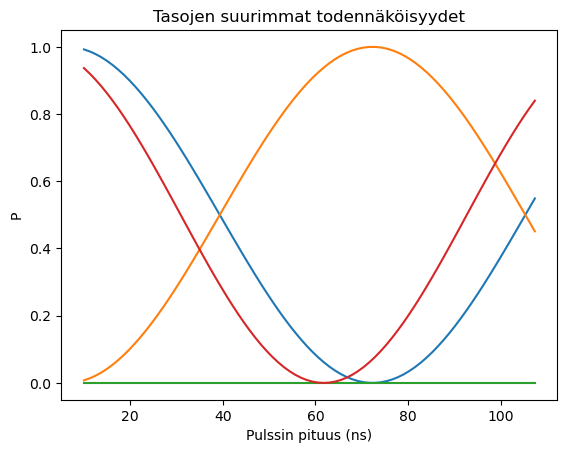

---------------------------------------------


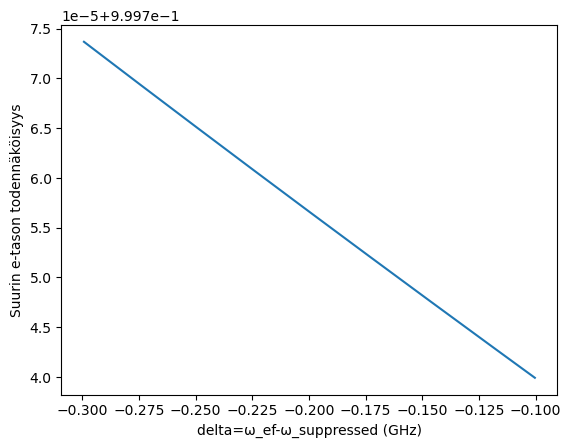

Amplitudi (GHz): 0.05634322412417695
AC-stark siirtymä (GHz): -0.29928877865964115
E-tason suurin todennäköisyys: 0.9998349349209275
Pulssin pituus (ns): 61.76569649382768
Rabi-taajuus (fourier):  0.009573429023562504


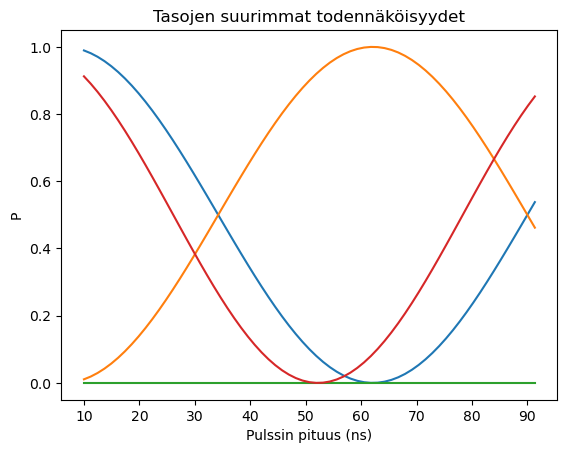

---------------------------------------------


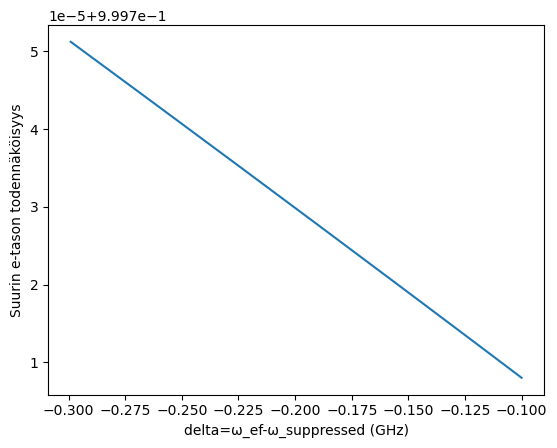

Amplitudi (GHz): 0.06506300881006147
AC-stark siirtymä (GHz): -0.29905076710210443
E-tason suurin todennäköisyys: 0.9998244894808866
Pulssin pituus (ns): 54.37023490007252
Rabi-taajuus (fourier):  0.011057645396394455


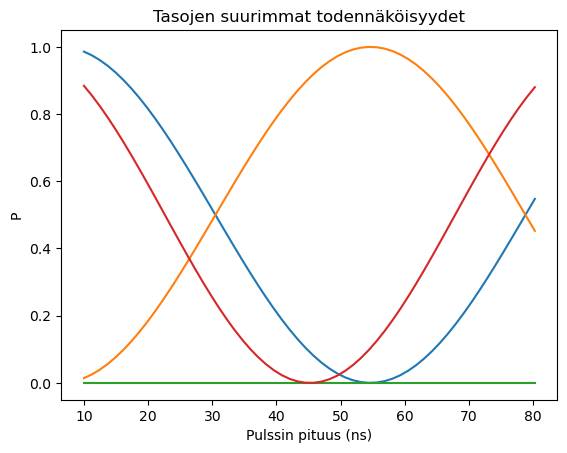

---------------------------------------------


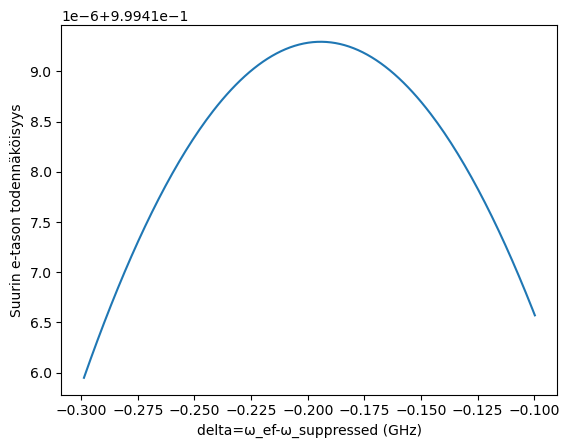

Amplitudi (GHz): 0.073782793495946
AC-stark siirtymä (GHz): -0.19477817498803618
E-tason suurin todennäköisyys: 0.9997512263996778
Pulssin pituus (ns): 49.439817964528714
Rabi-taajuus (fourier):  0.012530699169376843


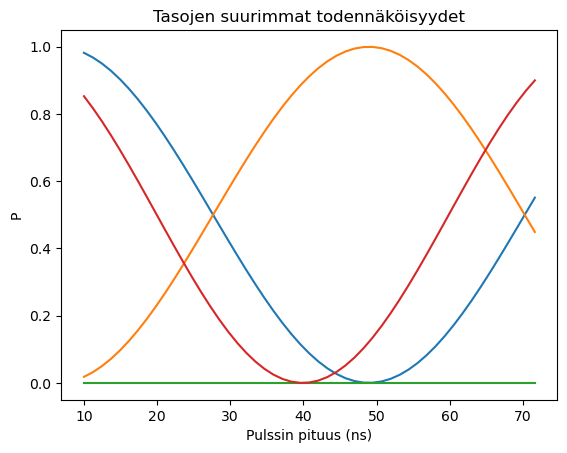

---------------------------------------------


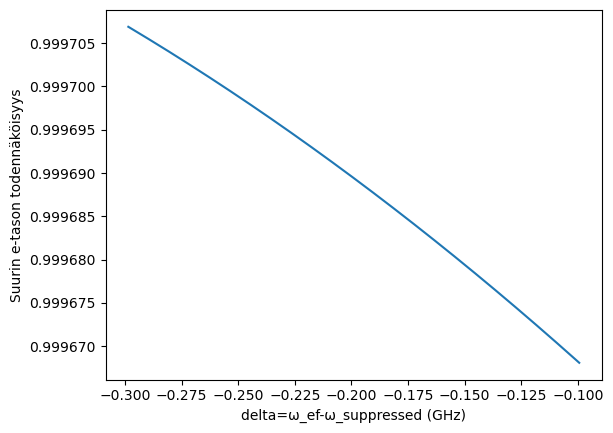

Amplitudi (GHz): 0.08250257818183053
AC-stark siirtymä (GHz): -0.29847100231743634
E-tason suurin todennäköisyys: 0.9997128491619973
Pulssin pituus (ns): 44.5094790048237
Rabi-taajuus (fourier):  0.014019374092222682


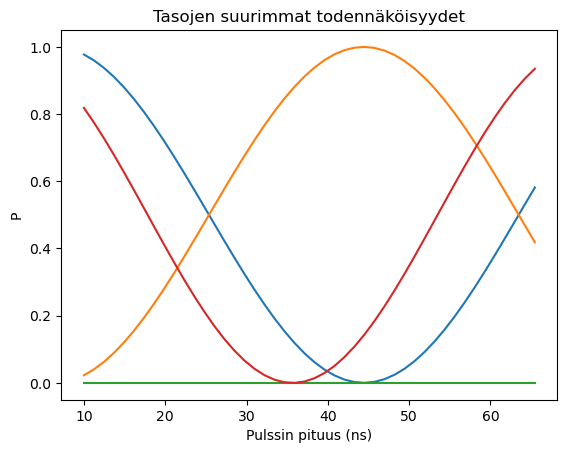

---------------------------------------------


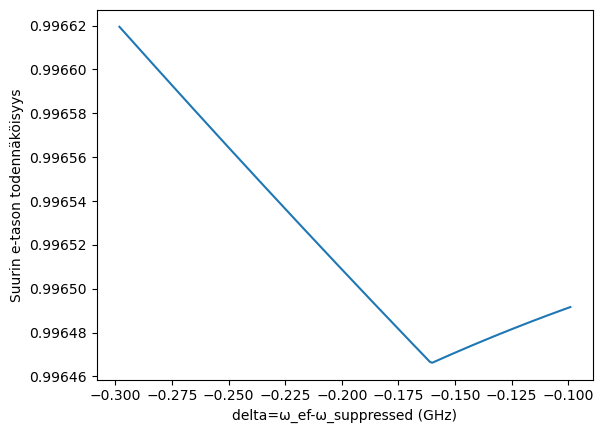

Amplitudi (GHz): 0.09122236286771505
AC-stark siirtymä (GHz): -0.298129249090305
E-tason suurin todennäköisyys: 0.9996551707970286
Pulssin pituus (ns): 39.57920327080291
Rabi-taajuus (fourier):  0.015491759058537977


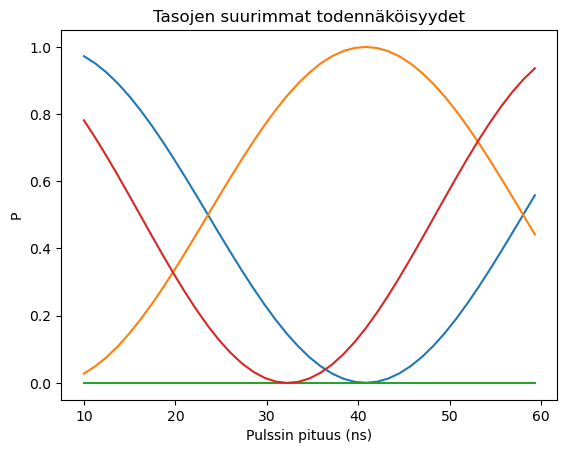

---------------------------------------------


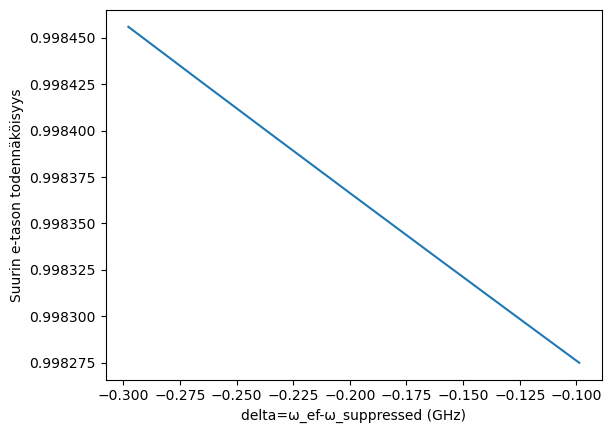

Amplitudi (GHz): 0.0999421475535996
AC-stark siirtymä (GHz): -0.29775291530664216
E-tason suurin todennäköisyys: 0.9994847847420644
Pulssin pituus (ns): 37.113890634369135
Rabi-taajuus (fourier):  0.014868443879666947


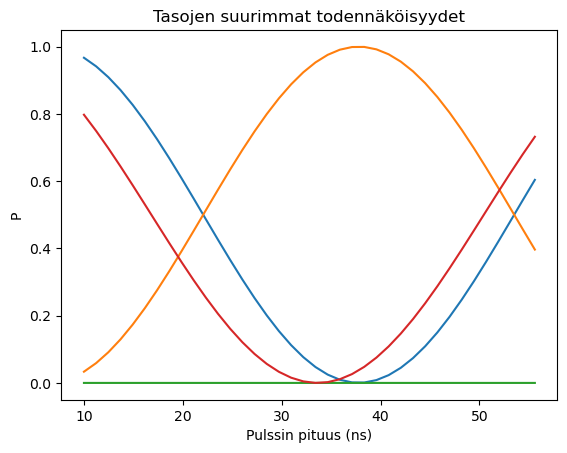

---------------------------------------------


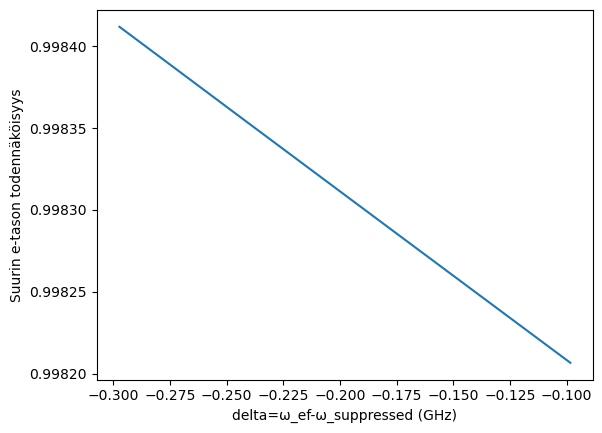

Amplitudi (GHz): 0.1086619322394841
AC-stark siirtymä (GHz): -0.2973420009664478
E-tason suurin todennäköisyys: 0.9994158203227326
Pulssin pituus (ns): 34.64869084085112
Rabi-taajuus (fourier):  0.016181808658143976


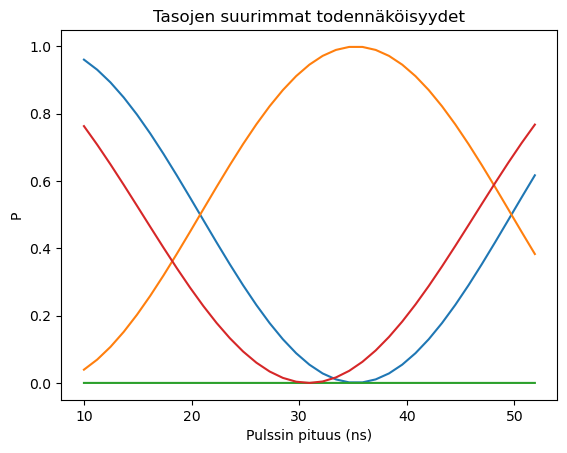

---------------------------------------------


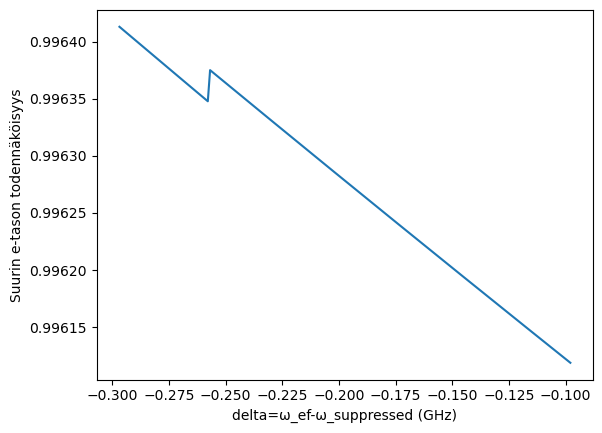

Amplitudi (GHz): 0.11738171692536864
AC-stark siirtymä (GHz): -0.2968965060697219
E-tason suurin todennäköisyys: 0.9993862416384256
Pulssin pituus (ns): 32.18345147062057
Rabi-taajuus (fourier):  0.01747664506606476


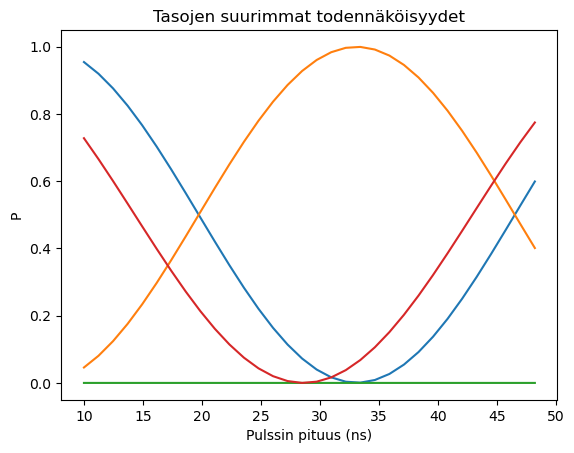

---------------------------------------------


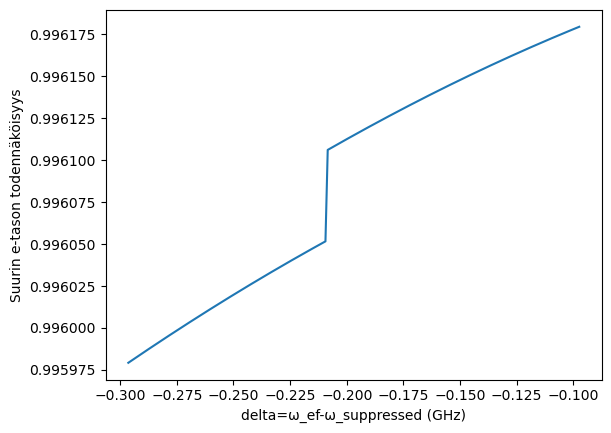

Amplitudi (GHz): 0.1261015016112532
AC-stark siirtymä (GHz): -0.09741643061646446
E-tason suurin todennäköisyys: 0.9992493959991099
Pulssin pituus (ns): 32.18312942319419
Rabi-taajuus (fourier):  0.02142382689502622


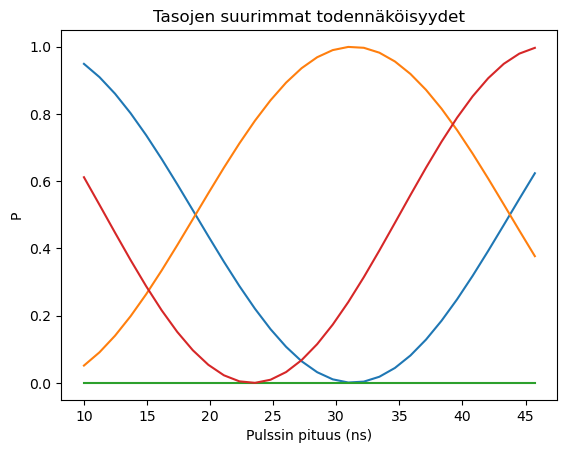

---------------------------------------------


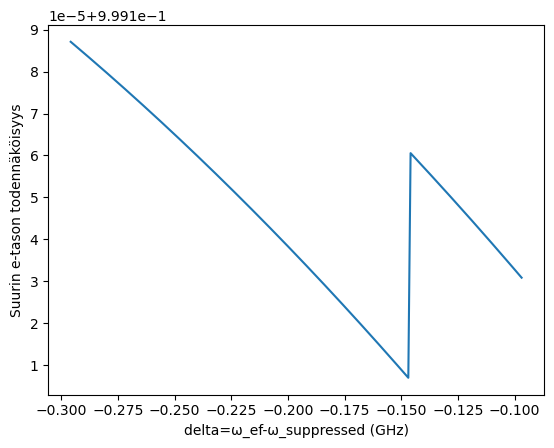

Amplitudi (GHz): 0.1348212862971377
AC-stark siirtymä (GHz): -0.2959017746066755
E-tason suurin todennäköisyys: 0.999204833230919
Pulssin pituus (ns): 29.717970116675552
Rabi-taajuus (fourier):  0.02288977580872104


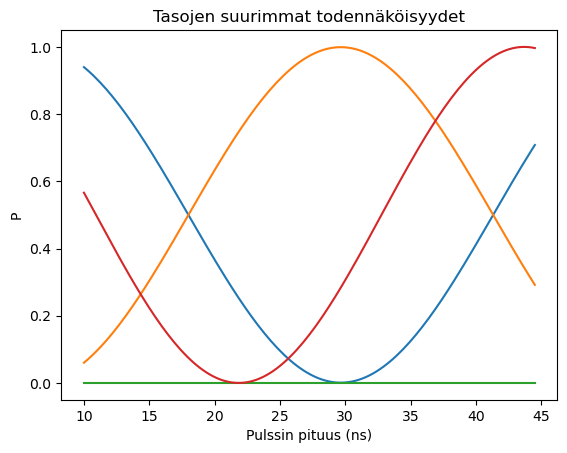

---------------------------------------------


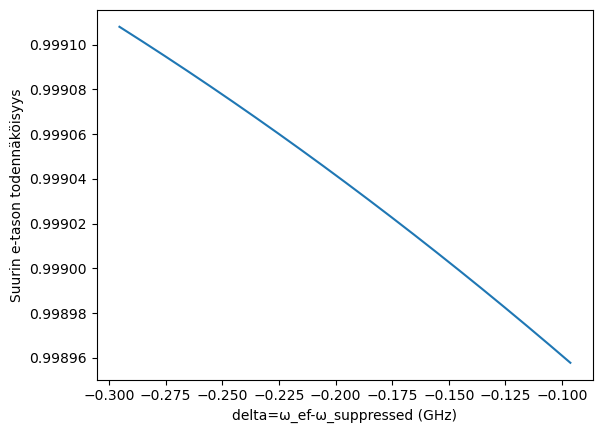

Amplitudi (GHz): 0.1435410709830222
AC-stark siirtymä (GHz): -0.295352538040355
E-tason suurin todennäköisyys: 0.9991080611972436
Pulssin pituus (ns): 28.23880094470807
Rabi-taajuus (fourier):  0.021338084013682767


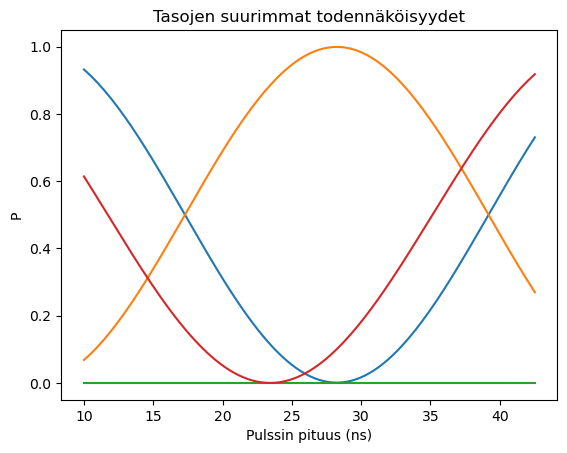

---------------------------------------------


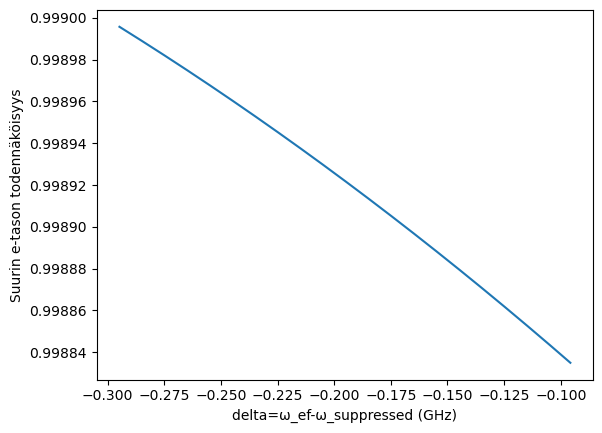

Amplitudi (GHz): 0.15226085566890676
AC-stark siirtymä (GHz): -0.29476872091750295
E-tason suurin todennäköisyys: 0.9989957853546878
Pulssin pituus (ns): 27.006120104883443
Rabi-taajuus (fourier):  0.022630709144433728


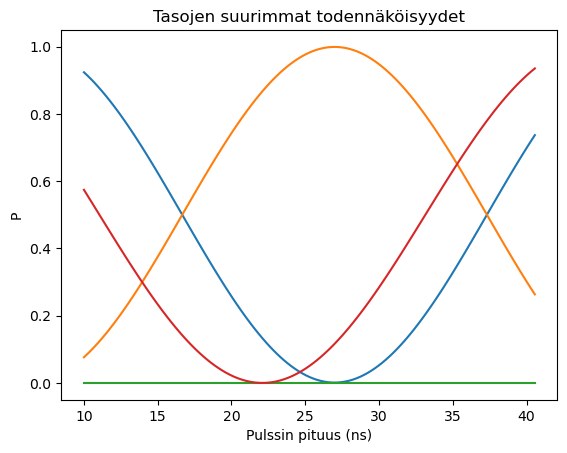

---------------------------------------------


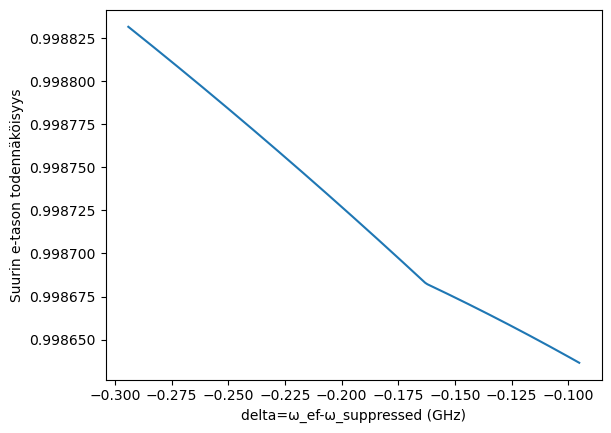

Amplitudi (GHz): 0.16098064035479126
AC-stark siirtymä (GHz): -0.29415032323811935
E-tason suurin todennäköisyys: 0.9988931850747241
Pulssin pituus (ns): 25.773490372727565
Rabi-taajuus (fourier):  0.023927619286098087


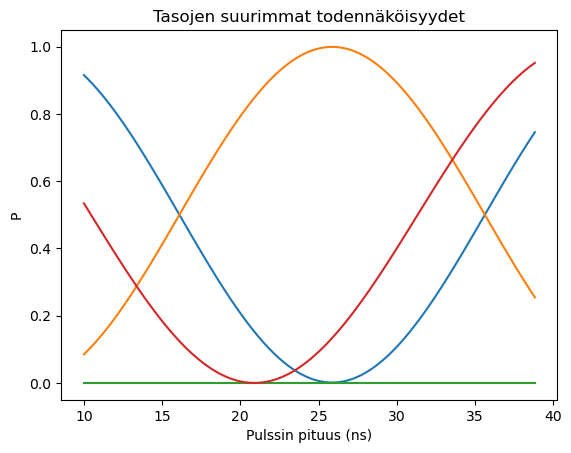

---------------------------------------------


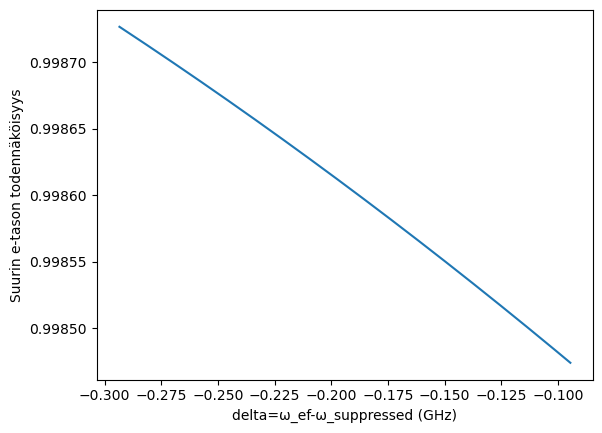

Amplitudi (GHz): 0.1697004250406758
AC-stark siirtymä (GHz): -0.29349734500220426
E-tason suurin todennäköisyys: 0.9987744743602671
Pulssin pituus (ns): 24.787338075721262
Rabi-taajuus (fourier):  0.02522440308653996


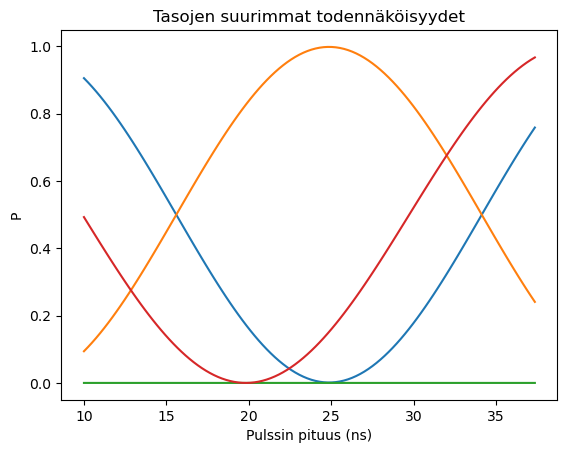

---------------------------------------------


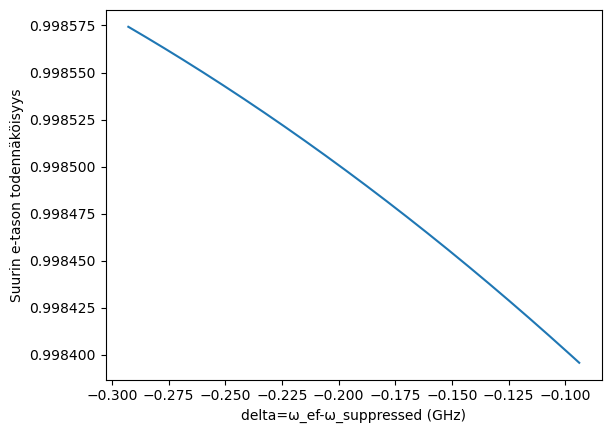

Amplitudi (GHz): 0.17842020972656034
AC-stark siirtymä (GHz): -0.2928097862097576
E-tason suurin todennäköisyys: 0.9986281391536933
Pulssin pituus (ns): 24.047636398914328
Rabi-taajuus (fourier):  0.026520405926554046


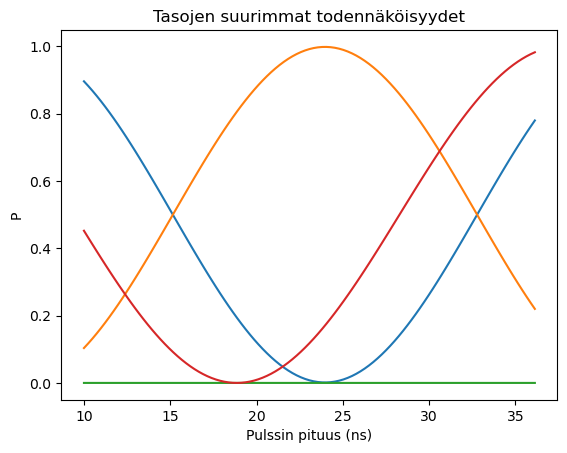

---------------------------------------------


In [7]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.0005
max_range = 0.0070
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_d_opt = qubit.frequency+list_AC_stark_vals[i]

    f_rabi=4*A/3 #Arvaus Rabi-taajuudelle
    AC_stark=0.2274*A**2- 0.0003122*A + 6.917e-06 #Arvaus AC-stark siirtymälle

    params=find_params(f_d_opt, A, evolution_eigenbasis,f_rabi,AC_stark,[-300,-100],1000)

    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    f_supp_opt = f_ef/3+deltas[-1]

    m=10
    if A < 0.13:
        vals = sim_pulse(f_d_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=5,p=5)
    else:
        vals = sim_pulse(f_d_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=5,p=1)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])
    
    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(0.012744300694754308), np.float64(0.021464085380638837), np.float64(0.030183870066523365), np.float64(0.03890365475240789), np.float64(0.04762343943829242), np.float64(0.05634322412417695), np.float64(0.06506300881006147), np.float64(0.073782793495946), np.float64(0.08250257818183053), np.float64(0.09122236286771505), np.float64(0.0999421475535996), np.float64(0.1086619322394841), np.float64(0.11738171692536864), np.float64(0.1261015016112532), np.float64(0.1348212862971377), np.float64(0.1435410709830222), np.float64(0.15226085566890676), np.float64(0.16098064035479126), np.float64(0.1697004250406758), np.float64(0.17842020972656034)]


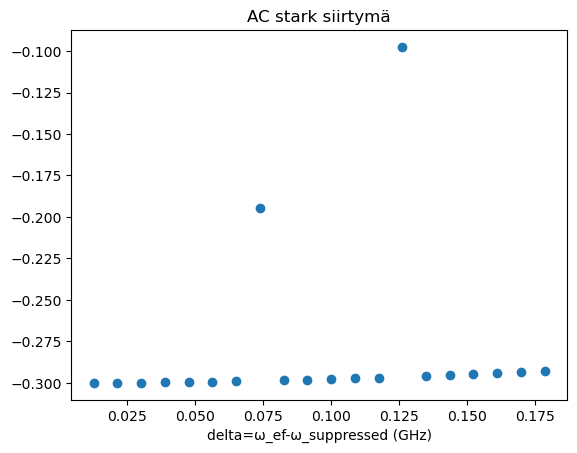

[np.float64(-0.2999601280993518), np.float64(-0.2998950193244727), np.float64(-0.29979532999306213), np.float64(-0.29966106010512), np.float64(-0.2994922096606463), np.float64(-0.29928877865964115), np.float64(-0.29905076710210443), np.float64(-0.19477817498803618), np.float64(-0.29847100231743634), np.float64(-0.298129249090305), np.float64(-0.29775291530664216), np.float64(-0.2973420009664478), np.float64(-0.2968965060697219), np.float64(-0.09741643061646446), np.float64(-0.2959017746066755), np.float64(-0.295352538040355), np.float64(-0.29476872091750295), np.float64(-0.29415032323811935), np.float64(-0.29349734500220426), np.float64(-0.2928097862097576)]


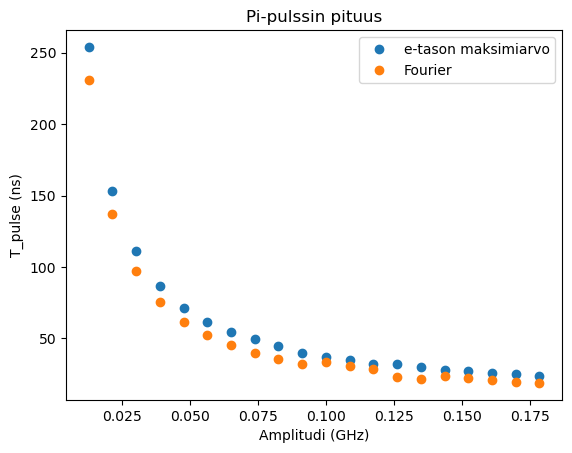

[np.float64(254.0442325173277), np.float64(152.975043730643), np.float64(111.06820975814617), np.float64(86.41705432102145), np.float64(71.62627264697414), np.float64(61.76569649382768), np.float64(54.37023490007252), np.float64(49.439817964528714), np.float64(44.5094790048237), np.float64(39.57920327080291), np.float64(37.113890634369135), np.float64(34.64869084085112), np.float64(32.18345147062057), np.float64(32.18312942319419), np.float64(29.717970116675552), np.float64(28.23880094470807), np.float64(27.006120104883443), np.float64(25.773490372727565), np.float64(24.787338075721262), np.float64(24.047636398914328)]


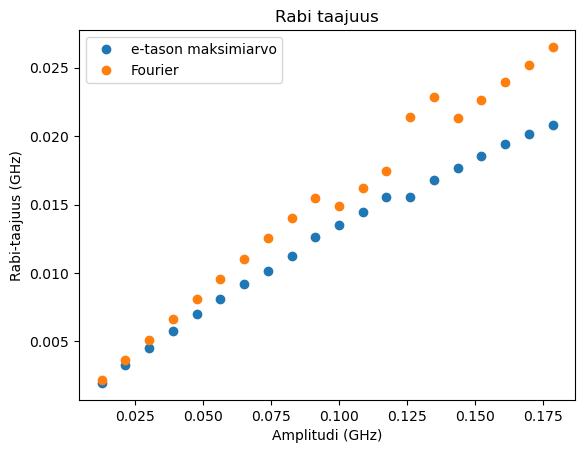

[np.float64(0.0021635422175466123), np.float64(0.003644381377009103), np.float64(0.00512690842942647), np.float64(0.00660967180928821), np.float64(0.008093189735230103), np.float64(0.009573429023562504), np.float64(0.011057645396394455), np.float64(0.012530699169376843), np.float64(0.014019374092222682), np.float64(0.015491759058537977), np.float64(0.014868443879666947), np.float64(0.016181808658143976), np.float64(0.01747664506606476), np.float64(0.02142382689502622), np.float64(0.02288977580872104), np.float64(0.021338084013682767), np.float64(0.022630709144433728), np.float64(0.023927619286098087), np.float64(0.02522440308653996), np.float64(0.026520405926554046)]


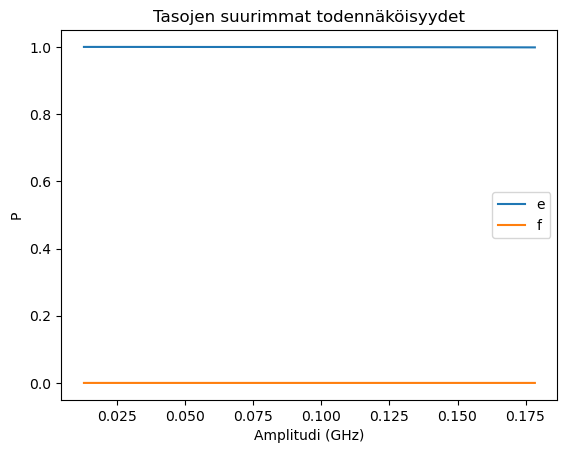

[np.float64(0.9999942980764295), np.float64(0.9999805361674756), np.float64(0.9999627830541293), np.float64(0.9999369882476044), np.float64(0.9999035171601366), np.float64(0.9998349349209275), np.float64(0.9998244894808866), np.float64(0.9997512263996778), np.float64(0.9997128491619973), np.float64(0.9996551707970286), np.float64(0.9994847847420644), np.float64(0.9994158203227326), np.float64(0.9993862416384256), np.float64(0.9992493959991099), np.float64(0.999204833230919), np.float64(0.9991080611972436), np.float64(0.9989957853546878), np.float64(0.9988931850747241), np.float64(0.9987744743602671), np.float64(0.9986281391536933)]
[np.float64(6.969042842355252e-10), np.float64(3.76535854453216e-09), np.float64(1.2111418880601393e-08), np.float64(2.972799489465393e-08), np.float64(6.175558709336029e-08), np.float64(1.1382438859106177e-07), np.float64(1.9448592425676872e-07), np.float64(2.720281957694964e-07), np.float64(4.7418850730363624e-07), np.float64(6.933392516507752e-07), np.flo

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.xlabel("delta=ω_ef-ω_suppressed (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason maksimiarvo","Fourier"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason maksimiarvo","Fourier"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(A_vals, e_vals)
plt.plot(A_vals, f_vals)
plt.legend(["e","f"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)